# Notebook for constructing age models for the Osler Volcanics

In [1]:
using Pkg
using Chron
using Plots, DelimitedFiles
using DataFrames, CSV
using Statistics, StatsBase

include("MCR_age_models.jl")

plot_posterior_paths (generic function with 1 method)

## Oslver Volcanic Group

- The bottom Osler porphyry was dated to be 1107.5 +4-2 Ma by Davis and Sutcliffe, 1985
- The Agate point rhyolite was dated to be 1105.15 $\pm$ 0.33 Ma by Swanson-Hysell et al., 2019
- The top of the reversed polarity section is defined by the angular unconformity between the Halls 1974 normal polarity poles and the top of the Agate Pioint rhyolite. The interpretation there is that our best cosntraint on the top of the section is that the top of the section is the age of the reversal to normal polarity boundary which is ca. 1100 Ma. I put a 1 Ma 2$\sigma$ uncertainty on this age given that we don't known when exactly the reversal occurred.

In [2]:
Osler_Name = ("Base of Osler", "Agate Point rhyolite flow", "Top of Osler") # Et cetera
Osler_Age           = [ 1107.5, 1105.15, 1100] # Measured ages
Osler_Age_sigma     = [ 2/2,     0.33/2,  0.5] # Measured 1-σ uncertainties
Osler_Height        = [ 0.0,     2700,  3200] # Depths below surface should be negative
Osler_Age_Sidedness = [0, 0, 0] # Sidedness (zeros by default: geochron constraints are two-sided). Use -1 for a maximum age and +1 for a minimum age, 0 for two-sided

Osler_Path = "../code_output/age_models/Osler_Volcanic_Group" # Where do you want output files to be stored

# construct the section (ChronAgeData object)
Osler_section = make_ChronAgeData(Osler_Name, Osler_Age, Osler_Age_sigma, Osler_Height, Osler_Age_Sidedness, Osler_Path, Age_Unit="Ma", Height_Unit="m")

ChronAgeData{3}(("Base of Osler", "Agate Point rhyolite flow", "Top of Osler"), [0.0, 2700.0, 3200.0], [0.01, 0.01, 0.01], [1107.5, 1105.15, 1100.0], [1.0, 0.165, 0.5], [NaN, NaN, NaN], [NaN, NaN, NaN], [NaN, NaN, NaN], [NaN, NaN, NaN], [0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [#undef, #undef, #undef], (:Chronometer, :Chronometer, :Chronometer), [NaN NaN NaN; NaN NaN NaN; … ; NaN NaN NaN; NaN NaN NaN], "../code_output/age_models/Osler_Volcanic_Group", 2, "Ma", "m", :cdf)

In [3]:
Osler_age_model_config, Osler_age_model_mdl, Osler_age_model_agedist, Osler_age_model_lldist = run_age_model(Osler_section, 10, 0.20, 1000, save_results=false, plot_results=false)

┌ Info: Generating stratigraphic age-depth model...
└ @ Chron /Users/yimingzhang/.julia/packages/Chron/OUVJN/src/StratMetropolis.jl:28
┌ Info: Burn-in: 449000 steps
└ @ Chron /Users/yimingzhang/.julia/packages/Chron/OUVJN/src/StratMetropolis.jl:626
Burn-in... 100%|█████████████████████████████████████████| Time: 0:00:00
┌ Info: Collecting sieved stationary distribution: 449000 steps
└ @ Chron /Users/yimingzhang/.julia/packages/Chron/OUVJN/src/StratMetropolis.jl:689
Collecting... 100%|██████████████████████████████████████| Time: 0:00:00


(StratAgeModelConfiguration(10.0, 449000, 1000, 449, 0.2), StratAgeModel([0.0, 10.0, 20.0, 30.0, 40.0, 50.0, 60.0, 70.0, 80.0, 90.0  …  3110.0, 3120.0, 3130.0, 3140.0, 3150.0, 3160.0, 3170.0, 3180.0, 3190.0, 3200.0], [1107.996909411217, 1107.986538498755, 1107.9789357738443, 1107.9698739425205, 1107.9540497891658, 1107.9452776330204, 1107.932749551503, 1107.9216877550607, 1107.9077822650675, 1107.894657806768  …  1101.197544829661, 1101.1077373935816, 1101.02975720788, 1100.9486502475338, 1100.85922452164, 1100.7726748877417, 1100.675560536995, 1100.5840114114085, 1100.494659802008, 1100.4080028585183], [0.5936777009739915, 0.5995781003791975, 0.6030653691444948, 0.6077737416507364, 0.617664281597981, 0.621846027313057, 0.6269145764296553, 0.6335335307876596, 0.6377255687399888, 0.6376199697376219  …  0.8630237891233669, 0.834595748246943, 0.8038506815268438, 0.778007069841426, 0.745115368827685, 0.7097833804054643, 0.6455134526437116, 0.5941583343362465, 0.52580597629853, 0.4727232308

### posterior summary age model

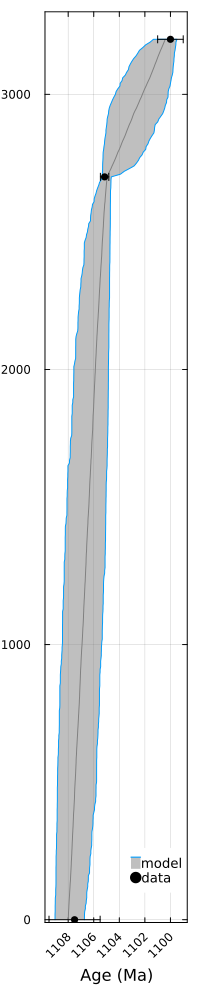

In [4]:
Osler_age_model = plot_age_model(Osler_section, Osler_age_model_mdl, save_figure=false)
plot!(ylim=(-10, 3300))
# savefig(Osler_age_model, Osler_section.Path*"_AgeDepthModel.pdf")
display(Osler_age_model)

### example posterior accumulation models

  0.003226 seconds (19.00 k allocations: 9.216 MiB)


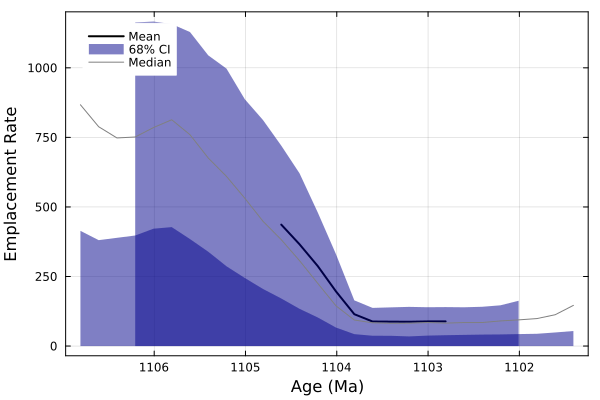

In [5]:
plot_accumulation_model(Osler_section, Osler_age_model_config, Osler_age_model_mdl, Osler_age_model_agedist, save_figure=false)

### example posterior age models

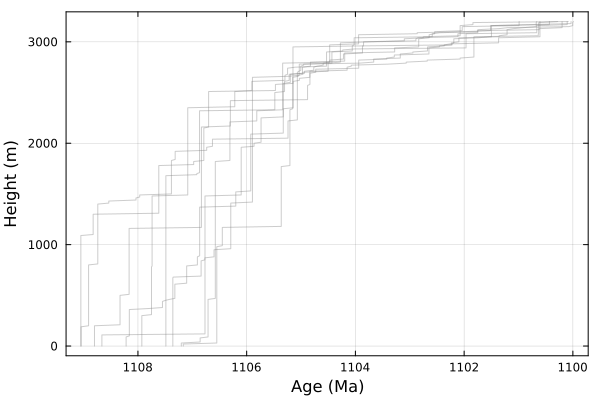

In [6]:
plot_posterior_paths(Osler_section, Osler_age_model_agedist, Osler_age_model_mdl)

## save the age models to a file

In [7]:
Osler_age_model_agedist

321×1000 Matrix{Float64}:
 1107.02  1107.61  1107.8   1107.07  …  1108.01  1107.4   1108.85  1107.06
 1107.02  1107.61  1107.8   1107.07     1108.01  1107.4   1108.85  1106.14
 1107.02  1106.93  1107.8   1107.07     1108.01  1107.4   1108.85  1106.14
 1107.02  1106.93  1107.8   1107.07     1108.01  1107.4   1108.85  1106.14
 1107.02  1106.93  1107.8   1107.07     1108.01  1107.22  1108.85  1106.14
 1107.02  1106.93  1107.8   1107.07  …  1108.01  1107.22  1108.85  1106.14
 1107.02  1106.93  1107.8   1107.07     1108.01  1107.22  1108.85  1106.14
 1107.02  1106.93  1107.8   1107.07     1108.01  1107.22  1108.85  1106.14
 1107.02  1106.93  1107.8   1107.07     1108.01  1107.22  1108.85  1106.14
 1107.02  1106.93  1107.8   1107.07     1108.01  1107.22  1108.85  1106.14
    ⋮                                ⋱                             
 1102.33  1100.69  1102.14  1101.46     1101.72  1101.69  1100.68  1100.01
 1102.06  1100.69  1100.98  1100.76     1101.72  1101.69  1099.77  1100.01
 1101.

In [8]:
# use the mdl.height as index, agedist as the data
Osler_age_models_df = DataFrame(hcat(Osler_age_model_mdl.Height, Osler_age_model_agedist), :auto)
# rename the first three columns to be site, height
rename!(Osler_age_models_df, Dict(:x1 => "height"))
Osler_age_models_df

Row,height,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14,x15,x16,x17,x18,x19,x20,x21,x22,x23,x24,x25,x26,x27,x28,x29,x30,x31,x32,x33,x34,x35,x36,x37,x38,x39,x40,x41,x42,x43,x44,x45,x46,x47,x48,x49,x50,x51,x52,x53,x54,x55,x56,x57,x58,x59,x60,x61,x62,x63,x64,x65,x66,x67,x68,x69,x70,x71,x72,x73,x74,x75,x76,x77,x78,x79,x80,x81,x82,x83,x84,x85,x86,x87,x88,x89,x90,x91,x92,x93,x94,x95,x96,x97,x98,x99,x100,⋯
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,⋯
1,0.0,1107.02,1107.61,1107.8,1107.07,1108.21,1107.82,1107.78,1108.22,1108.28,1107.7,1107.78,1107.9,1107.9,1107.89,1107.78,1108.01,1108.2,1108.67,1108.7,1107.4,1108.24,1107.83,1108.07,1108.63,1108.76,1107.11,1107.55,1107.17,1108.96,1108.86,1107.32,1107.33,1108.78,1107.97,1108.58,1107.73,1107.17,1107.99,1106.72,1107.97,1108.31,1108.49,1107.48,1108.66,1108.42,1108.12,1108.06,1107.51,1109.11,1108.47,1109.15,1107.9,1108.24,1107.95,1108.4,1107.78,1109.09,1109.01,1108.75,1108.77,1108.39,1107.83,1108.94,1107.95,1108.11,1107.25,1107.66,1107.43,1108.44,1107.69,1107.36,1108.56,1107.9,1107.68,1108.88,1108.25,1109.04,1107.53,1107.75,1107.0,1107.7,1107.55,1108.13,1107.26,1107.81,1108.19,1108.22,1108.25,1106.81,1107.65,1108.17,1108.2,1108.7,1108.56,1107.78,1108.08,1107.54,1108.01,1108.02,⋯
2,10.0,1107.02,1107.61,1107.8,1107.07,1108.21,1107.82,1107.78,1108.22,1108.28,1107.7,1107.78,1107.9,1107.9,1107.89,1107.78,1108.01,1108.2,1108.67,1108.7,1107.4,1108.24,1107.83,1108.07,1108.63,1108.76,1107.11,1107.55,1107.17,1108.96,1108.86,1107.32,1107.33,1108.78,1107.97,1108.58,1107.73,1107.17,1107.99,1106.72,1107.97,1108.31,1108.49,1107.48,1108.66,1108.42,1108.12,1108.06,1107.51,1109.11,1108.47,1109.15,1107.9,1108.24,1107.95,1108.4,1107.78,1109.09,1109.01,1108.75,1108.77,1108.39,1107.83,1108.94,1107.95,1108.11,1107.25,1107.66,1107.43,1108.44,1107.69,1107.36,1108.56,1107.9,1107.5,1108.88,1108.25,1108.95,1107.53,1107.75,1107.0,1107.7,1107.55,1108.13,1107.26,1107.81,1108.19,1108.22,1108.25,1106.81,1107.65,1108.17,1108.2,1108.7,1108.56,1107.78,1108.08,1107.54,1108.01,1108.02,⋯
3,20.0,1107.02,1106.93,1107.8,1107.07,1108.21,1107.82,1107.78,1108.22,1108.28,1107.7,1107.78,1107.9,1107.9,1107.89,1107.78,1108.01,1108.2,1108.67,1108.7,1107.4,1108.24,1107.83,1108.07,1108.63,1108.76,1107.11,1107.55,1107.17,1108.96,1108.86,1107.32,1107.33,1108.78,1107.97,1108.58,1107.73,1107.17,1107.99,1106.72,1107.97,1108.31,1108.49,1107.48,1108.66,1108.42,1108.12,1108.06,1107.51,1109.11,1108.47,1109.15,1107.9,1108.24,1107.95,1108.4,1107.78,1109.09,1109.01,1108.75,1108.77,1108.39,1107.83,1108.94,1107.95,1108.11,1107.25,1107.66,1107.43,1108.44,1107.69,1107.36,1108.56,1107.9,1107.5,1108.88,1108.25,1108.95,1107.53,1107.75,1107.0,1107.7,1107.55,1108.13,1107.26,1107.81,1108.19,1108.22,1108.25,1106.81,1107.65,1108.17,1108.2,1108.7,1108.56,1107.78,1108.08,1107.54,1108.01,1108.02,⋯
4,30.0,1107.02,1106.93,1107.8,1107.07,1108.21,1107.82,1107.78,1108.22,1108.28,1107.7,1107.78,1107.9,1107.9,1107.89,1107.78,1108.01,1108.2,1108.67,1108.7,1107.4,1108.24,1107.83,1108.07,1108.63,1108.76,1107.11,1107.55,1107.17,1108.96,1108.86,1107.32,1107.33,1108.78,1107.97,1108.58,1107.73,1107.17,1107.99,1106.72,1107.97,1108.31,1108.49,1107.48,1108.66,1108.42,1108.12,1108.06,1107.51,1109.11,1108.47,1109.15,1107.9,1108.24,1107.95,1108.4

In [9]:
# write the DataFrame to a csv file
CSV.write(Osler_section.Path*"_posterior_ages.csv", Osler_age_models_df)

"../code_output/age_models/Osler_Volcanic_Group_posterior_ages.csv"